In [1]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.4 MB/s eta 0:00:00


In [2]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=646b990553d6643bd0806eff4ded3d3a45bfbc30a3210f8cb35b74a3d0dd3718
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
!pip install qiskit

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt
import qiskit

print("Versão do Qiskit:", qiskit.__version__)


Versão do Qiskit: 2.2.3


## Imports

In [13]:
from math import pi

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt
import qiskit

print("Versão do Qiskit:", qiskit.__version__)

Versão do Qiskit: 2.2.3


# Hands on - Teleporte Quantico

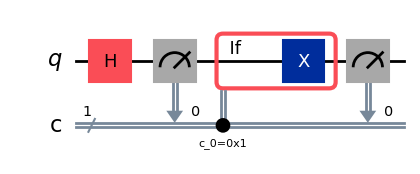

{'0': 1024}


In [28]:
qr = QuantumRegister(1, "q")
cr = ClassicalRegister(1, "c")
test = QuantumCircuit(qr, cr)
(q0,) = qr
(c0,) = cr

test.h(q0)
test.measure(q0, c0)

with test.if_test((c0, 1)):
    test.x(q0)

test.measure(q0, c0)
display(test.draw("mpl"))

sim = AerSimulator()
res = sim.run(transpile(test, sim), shots=1024).result()
print(res.get_counts())


**Circuito de teleporte**

q0 = qubit com o estado |ψ⟩ que queremos teletransportar (Alice)

q1 = metade do par EPR de Alice

q2 = qubit de Bob

c0 = medida de q0

c1 = medida de q1

c2 = medida final de Bob

In [29]:
def build_teleport_dynamic(theta=pi/4):
    """
    Teleporte quântico com correções X/Z dinâmicas em Qiskit 2.2.3.

    theta define o estado |ψ> = RY(theta)|0> preparado em q0.
    """

    # Qubits: q0 (estado), q1 (Alice), q2 (Bob)
    qr = QuantumRegister(3, "q")
    # Bits clássicos: c0, c1 (Alice), c2 (Bob final)
    cr = ClassicalRegister(3, "c")
    qc = QuantumCircuit(qr, cr)

    q0, q1, q2 = qr
    c0, c1, c2 = cr

    # 1) Preparar o estado em q0 com RY(theta), como no tutorial
    qc.ry(theta, q0)

    # 2) Criar par emaranhado entre q1 e q2
    qc.h(q1)
    qc.cx(q1, q2)

    # 3) Medida de Bell em q0 e q1
    qc.cx(q0, q1)
    qc.h(q0)

    # 4) Medir os qubits de Alice (mid-circuit)
    qc.measure(q0, c0)
    qc.measure(q1, c1)

    # 5) Correções dinâmicas em Bob (q2), usando if_test
    #    se c1 == 1 -> X em Bob
    with qc.if_test((c1, 1)):
        qc.x(q2)

    #    se c0 == 1 -> Z em Bob
    with qc.if_test((c0, 1)):
        qc.z(q2)

    # 6) Medida final de Bob
    qc.measure(q2, c2)

    return qc

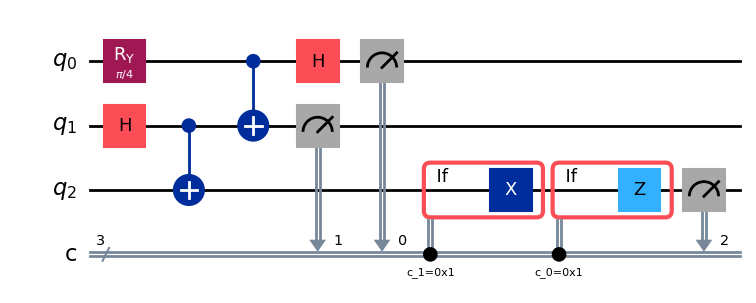

In [30]:
theta = pi/4
qc_teleport = build_teleport_dynamic(theta)
qc_teleport.draw("mpl")

#Simulando o teleporte

c2 é Bob depois da correção

c1 e c0 são os resultados de Alice

In [31]:
sim = AerSimulator()

qc_t = transpile(qc_teleport, sim)
result = sim.run(qc_t, shots=4096).result()
counts = result.get_counts()

print("Counts (bitstring = c2 c1 c0):")
print(counts)
plt.show()


Counts (bitstring = c2 c1 c0):
{'101': 159, '110': 165, '001': 821, '100': 153, '011': 887, '111': 179, '000': 875, '010': 857}


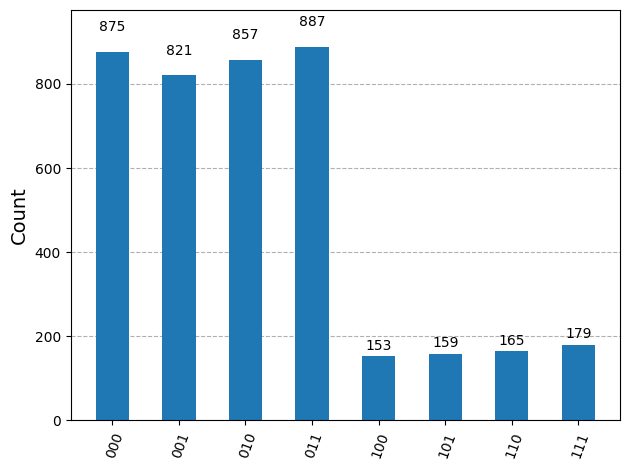

In [32]:
plot_histogram(counts)

Pra “ver o teleporte acontecendo”:
comparamos:

medir diretamente RY(theta)|0⟩

medir o qubit de Bob depois do teleporte

Se os histogramas forem iguais → teleporte funcionou.

In [38]:
def distribution_direct(theta=pi/4):
    """Mede diretamente o estado RY(theta)|0> em um qubit."""
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    qc.measure(0, 0)

    sim = AerSimulator()
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=4096).result()
    return result.get_counts()

def distribution_bob_after_teleport(theta=pi/4):
    """Pega só o bit de Bob (c2) do circuito de teleporte dinâmico."""
    qc = build_teleport_dynamic(theta)
    sim = AerSimulator()
    qc_t = transpile(qc, sim)
    result = sim.run(qc_t, shots=4096).result()
    counts_full = result.get_counts()

    # Somar apenas por bit de Bob (c2 = primeiro bit da string c2 c1 c0)
    from collections import Counter
    agg = Counter()
    for bitstring, c in counts_full.items():
        b = bitstring[0]  # c2
        agg[b] += c
    return dict(agg)


theta = pi/4

orig = distribution_direct(theta)
bob = distribution_bob_after_teleport(theta)

print("Medindo o estado preparado diretamente (|ψ>):")
print(orig)
plt.show()

print("Medindo Bob depois do teleporte (com correção dinâmica):")
print(bob)
plt.show()


Medindo o estado preparado diretamente (|ψ>):
{'0': 3532, '1': 564}
Medindo Bob depois do teleporte (com correção dinâmica):
{'1': 575, '0': 3521}


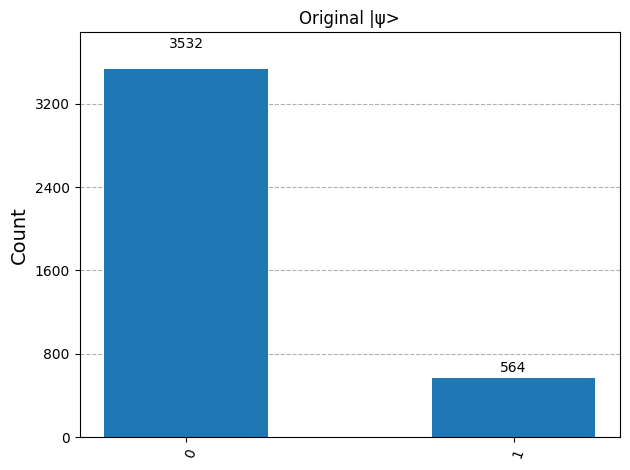

In [39]:
plot_histogram(orig, title="Original |ψ>")

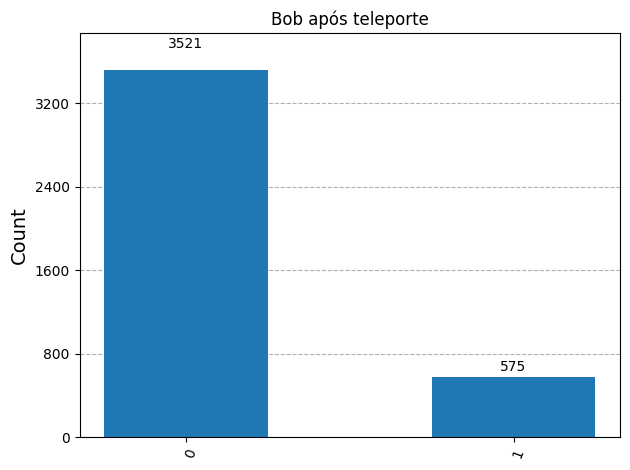

In [40]:
plot_histogram(bob, title="Bob após teleporte")